In [1]:
import geopandas as gpd
import shapely
import pandas as pd
from matplotlib import pyplot as plt

## Join kommun and stadsdelsområden into single layer
- Cut out sthlm kommun, insert stadsdelsområden in its place
- source of truth at boundaries is stadsdelsområden

In [4]:
kommuner = gpd.read_file("sthlm-lan-kommuner.geojson")
stadsdels_omraden = gpd.read_file("sthlm-stadsdelsområden-clean.geojson")
stadsdelar = gpd.read_file("sthlm-kommun-stadsdelar.geojson")
smallest_districts = gpd.read_file("sthlm-lan-max-detail.geojson")

,municipality_id,geometry
0,0180,"POLYGON ((18.09794 59.22891, 18.10803 59.22725..."
1,0136,"POLYGON ((18.94119 58.85713, 18.9404 58.85751,..."


,stadsdels_omrade,geometry
0,Bromma,"POLYGON ((17.93388 59.31993, 17.92867 59.32137..."
1,Enskede-Årsta-Vantörs,"POLYGON ((18.05223 59.24672, 18.05 59.2449, 18..."


,stadsdels_omrade,geometry
0,Bromma,"POLYGON ((17.93388 59.31993, 17.92867 59.32137..."
1,Enskede-Årsta-Vantörs,"POLYGON ((18.05223 59.24672, 18.05 59.2449, 18..."
2,Farsta,"POLYGON ((18.11656 59.23156, 18.10813 59.2296,..."
3,Hägersten-Älvsjö,"POLYGON ((17.98034 59.26257, 17.9803 59.26296,..."
4,Hässelby-Vällingby,"POLYGON ((17.89391 59.36608, 17.89545 59.36589..."
5,Järva,"POLYGON ((17.90185 59.36577, 17.90091 59.36614..."
6,Kungsholmens,"POLYGON ((17.99483 59.31743, 17.99195 59.31697..."
7,Norra innerstadens,"POLYGON ((18.07447 59.32907, 18.07051 59.32898..."
8,Skarpnäcks,"POLYGON ((18.18359 59.24616, 18.18626 59.24675..."
9,Skärholmens,"POLYGON ((17.9192 59.27943, 17.91528 59.27896,..."


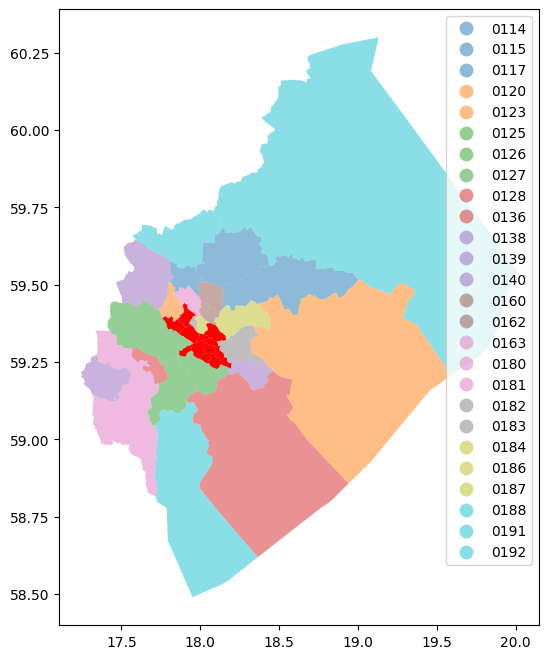

In [ ]:
# visualize 
display(kommuner.head(2))
display(stadsdels_omraden.head(2))
fig, ax = plt.subplots(1,1, figsize=(8,8))
kommuner.plot(column="municipality_id", ax=ax, alpha=0.5, legend=True)
stadsdels_omraden.plot(ax=ax, color="red", label="stadsdelsområden");

In [ ]:
kommuner_with_hole = kommuner.copy()
kommuner_with_hole.geometry = kommuner.difference(stadsdels_omraden.union_all())  # cut out stadsdelsområden (update borders of kommuner)
joined = pd.concat([kommuner_with_hole, stadsdels_omraden])  # put stadsdelsområden back in

joined = joined[joined["municipality_id"] != "0180"]

,municipality_id,geometry,stadsdels_omrade
1,0136,"POLYGON ((18.88299 58.82794, 18.87661 58.82481...",NaN
2,0183,"POLYGON ((17.93877 59.3716, 17.93877 59.3716, ...",NaN
3,0182,"POLYGON ((18.17308 59.3243, 18.17548 59.32449,...",NaN
4,0114,"POLYGON ((17.95049 59.48596, 17.94883 59.48642...",NaN
5,0117,"POLYGON ((18.47506 59.46335, 18.46698 59.45701...",NaN
6,0120,"POLYGON ((18.34969 59.3319, 18.36252 59.33558,...",NaN
7,0123,"POLYGON ((17.85521 59.38918, 17.85109 59.38751...",NaN
8,0127,"POLYGON ((17.91918 59.22719, 17.92839 59.22251...",NaN
9,0115,"POLYGON ((18.43213 59.56517, 18.43152 59.56537...",NaN
10,0163,"POLYGON ((17.95946 59.4077, 17.95289 59.41043,...",NaN


In [37]:
# add fake kommunid to sthlm kommun stadsdelsområden
x = joined["municipality_id"].isna()
ids = pd.Series(["0180" + f"-{n}" for n in range(len(x))])
joined["municipality_id"] = joined["municipality_id"].fillna(ids)

# add kommun namn, keep existing staddelsområdesnamn
joined = joined.rename(columns={"stadsdels_omrade": "municipality_name"})
kod_to_name = {
    "0114": "Upplands Väsby",
    "0115": "Vallentuna",
    "0117": "Österåker",
    "0120": "Värmdö",
    "0123": "Järfälla",
    "0125": "Ekerö",
    "0126": "Huddinge",
    "0127": "Botkyrka",
    "0128": "Salem",
    "0136": "Haninge",
    "0138": "Tyresö",
    "0139": "Upplands-Bro",
    "0140": "Nykvarn",
    "0160": "Täby",
    "0162": "Danderyd",
    "0163": "Sollentuna",
    "0180": "Stockholm",
    "0181": "Södertälje",
    "0182": "Nacka",
    "0183": "Sundbyberg",
    "0184": "Solna",
    "0186": "Lidingö",
    "0187": "Vaxholm",
    "0188": "Norrtälje",
    "0191": "Sigtuna",
    "0192": "Nynäshamn",
}
joined["municipality_name"] = joined["municipality_name"] .fillna(joined["municipality_id"].map(lambda x: kod_to_name.get(x, x)))

joined.to_file("kommuner_processed-2.geojson")

## Align stadsdelsområden and stadsdelar
- not actually exact overlap in real map, but update stadsdelsområden to match anyway since its
  nicer imo
- also assign område to each stadsdel (dont think sjoin works because of the overlap at boundaries)

In [ ]:
print(stadsdelar.sindex.valid_query_predicates)

inter = stadsdelar.overlay(stadsdels_omraden, how="intersection")
inter["area"] = inter.area
best = inter.sort_values("area", ascending=False).drop_duplicates(subset="NAMN")

joined = stadsdelar.merge(best[["NAMN", "Namn"]], on="NAMN", how="left")

In [ ]:
stadsdelar_clean = (joined
          .rename(columns={"NAMN": "name", "Namn": "stadsdels_omrade"})
          .drop(columns=["KATEGORI"], errors="ignore")
)
stadsdelar_clean["name"] = stadsdelar_clean["name"].str.title()

In [ ]:
stadsdels_omraden_clean = stadsdelar_clean.dissolve(by="stadsdels_omrade")

In [ ]:
stadsdelar_clean.to_file("sthlm-stadsdelar-clean.geojson")
stadsdels_omraden_clean.to_file("sthlm-stadsdelsomraden-clean.geojson")

## Merge full-detail and stadsdelar

In [119]:
stadsdelar = gpd.read_file("sthlm-stadsdelar-clean.geojson")
detailed = gpd.read_file("sthlm-lan-max-detail.geojson")
kommuner = gpd.read_file("sthlm-lan-kommuner.geojson")

# fix up detailed
detailed.geometry = detailed.make_valid()
detailed.drop(columns=["county_id"], inplace=True)

def drop_enclaves(gdf: gpd.GeoDataFrame):

    # tolerance for floating-point / topology noise
    TOL = 1e-4

    gdf = gdf.copy().reset_index(drop=True)
    gdf["orig_id"] = gdf.index

    # optional but often helpful
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf["geometry"] = gdf.geometry.make_valid()

    left = gdf[["orig_id", "geometry"]].copy()
    right = gdf[["orig_id", "geometry"]].copy()

    # candidate neighbors: polygons that only touch on boundaries
    pairs = left.sjoin(
        right,
        predicate="touches",
        how="inner",
        lsuffix="l",
        rsuffix="r"
    )

    pairs = pairs[pairs["orig_id_l"] != pairs["orig_id_r"]].copy()

    # compute shared boundary length with each touching neighbor
    left_geom = gdf.set_index("orig_id").geometry
    right_geom = left_geom

    pairs["shared_len"] = pairs.apply(
        lambda r: left_geom.loc[r["orig_id_l"]]
            .boundary
            .intersection(right_geom.loc[r["orig_id_r"]].boundary)
            .length,
        axis=1
    )

    # total perimeter of each polygon
    perim = gdf.set_index("orig_id").geometry.length
    pairs["perim_l"] = pairs["orig_id_l"].map(perim)

    # fraction of boundary shared with that neighbor
    pairs["share_frac"] = pairs["shared_len"] / pairs["perim_l"]

    # choose the best neighbor per polygon
    best = pairs.sort_values(["orig_id_l", "share_frac"], ascending=[True, False]) \
                .drop_duplicates("orig_id_l")

    # enclave = polygon whose boundary is almost entirely shared with one neighbor
    enclaves = best[best["share_frac"] >= 1 - TOL].copy()

    # map enclave -> surrounding polygon
    merge_map = dict(zip(enclaves["orig_id_l"], enclaves["orig_id_r"]))

    # assign each polygon to the group it should end up in
    gdf["group_id"] = gdf["orig_id"].map(lambda x: merge_map.get(x, x))

    # dissolve enclaves into their surrounding polygon
    result = gdf.dissolve(by="group_id", aggfunc="first").reset_index(drop=True)
    return result

detailed_no_enclaves = drop_enclaves(detailed)

detailed.shape

/var/folders/vy/y6v2xt3132qc90p4yqf3dmd00000gn/T/ipykernel_88769/3863661896.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  perim = gdf.set_index("orig_id").geometry.length


(524, 4)

(459, 4) (117, 3)


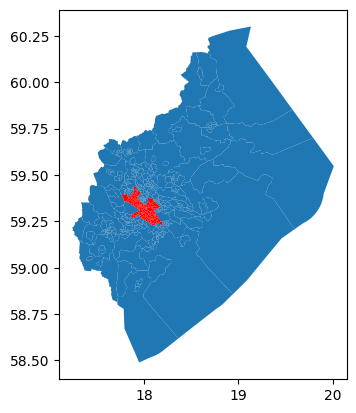

In [142]:
detailed_with_hole = detailed.copy()
detailed_with_hole.geometry= detailed_with_hole.difference(stadsdelar.union_all())
detailed_with_hole = detailed_with_hole[~detailed_with_hole.is_empty]

print(detailed_with_hole.shape, stadsdelar.shape)

ax = detailed_with_hole.plot()
stadsdelar.plot(ax=ax, color="red")

detailed_clean = pd.concat([stadsdelar, detailed_with_hole])

In [ ]:
detailed_clean["stadsdel_id"] = detailed_clean.index 
detailed_clean.drop(columns=["object_id"], inplace=True, errors="ignore")
# detailed_clean.rename(columns={})
print(detailed_clean[["name", "object_name"]].to_clipboard())

detailed_clean["name"] = detailed_clean["name"].combine_first(detailed_clean["object_name"])

detailed_clean.to_file("sthlm-lan-all-stadsdelar.geojson")

None
